<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml14_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clustering(군집화)

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# 데이터 셋

In [3]:
!wget https://bit.ly/fruits_300_data -O fruits.npy

--2026-08-12 01:14:33--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-08-12 01:14:33--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-08-12 01:14:34--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... conne

*   Jupyter notebook 코드셀에 linux 명령을 사용할 수 있음.
>   `!linux_command options`
*   `wget URL -O file_name`
    *   URL 주소의 파일을 다운로드해서 `file_name` 이름의 파일로 저장.
*   확장자 npy 파일: numpy 배열을 바이너리 형식으로 저장한 파일.
    *   `numpy.load(file_name)`: npy 형식의 파일을 읽어서 ndarray로 반환.

In [4]:
fruits = np.load(file='fruits.npy')

In [5]:
fruits.shape
#> shape: (300, 100, 100) = (n_samples, height, width)
#> 100x100 pixel 크기의 흑백 이미지 300개를 numpy 배열(ndarray)로 저장한 데이터 셋.

(300, 100, 100)

## 데이터 시각화

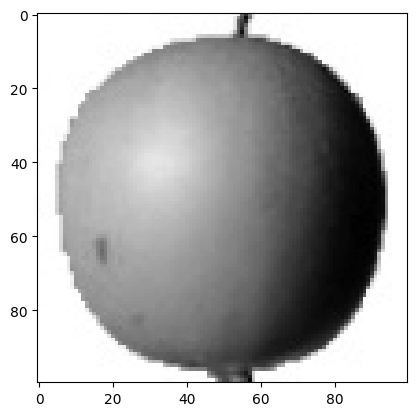

In [6]:
plt.imshow(fruits[0], cmap=plt.cm.binary)
plt.show()

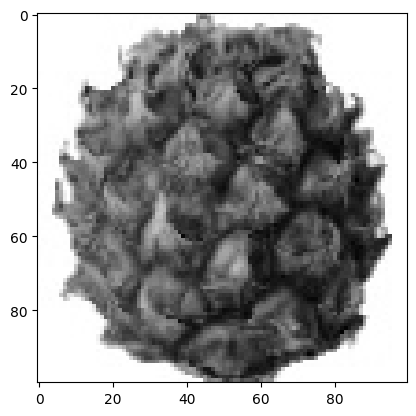

In [7]:
plt.imshow(fruits[100], cmap=plt.cm.binary)
plt.show()

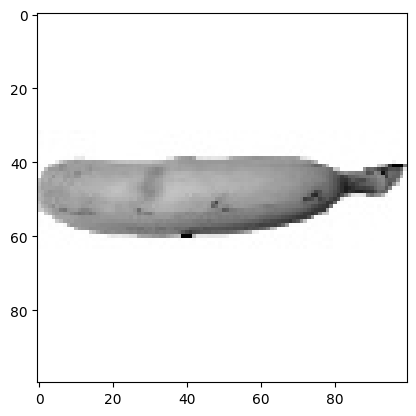

In [8]:
plt.imshow(fruits[200], cmap=plt.cm.binary)
plt.show()

배열의 이미지를 100개씩(10x10) 시각화

In [14]:
def plot_img_array(arr, ncols=10):
    # arr: (n_samples, height, width) 모양의 3차원 배열.
    # ncols: Axes(서브 플롯)의 열(column) 개수

    n = len(arr)  # 배열의 아이템(2차원 배열) 개수
    nrows = int(np.ceil(n / ncols))  # Axes(서브 플롯)의 행(row) 개수

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    #> figsize=(figure_width, figure_height) 설정.

    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            if idx < n:  # 인덱스 idx는 배열 arr의 아이템 개수보다 크면 안되기 때문에.
                img = arr[idx]
                axes[i, j].imshow(img, cmap=plt.cm.binary)
            axes[i, j].axis('off')

    plt.show()

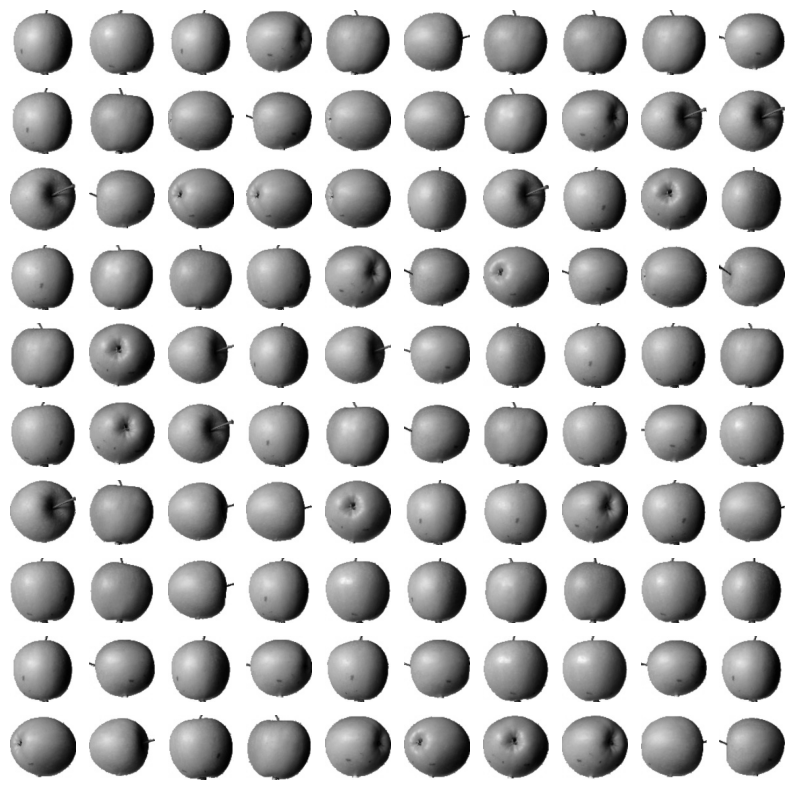

In [18]:
plot_img_array(fruits[:100])

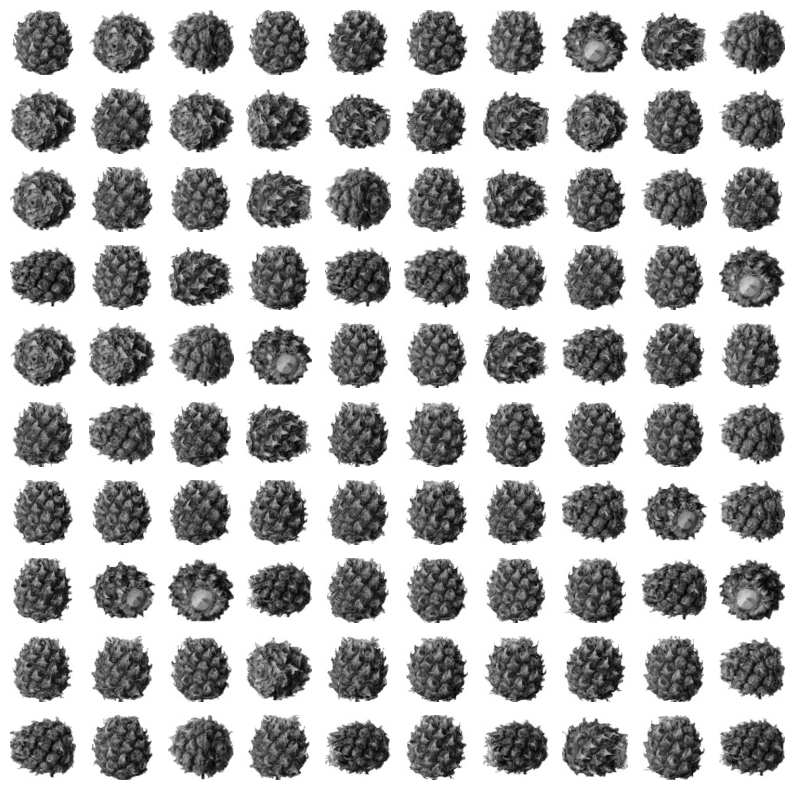

In [19]:
plot_img_array(fruits[100:200])

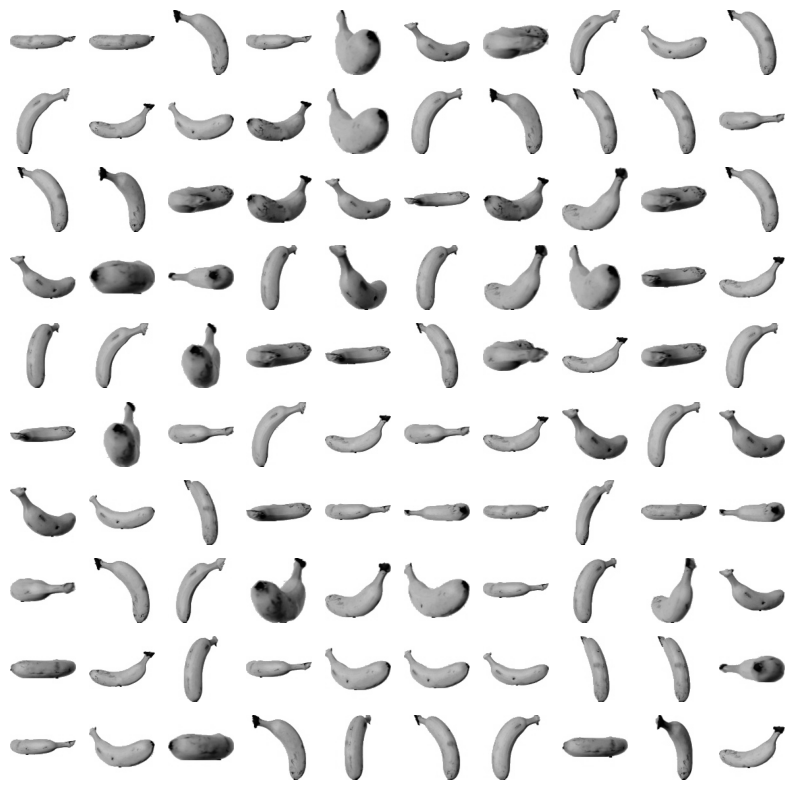

In [20]:
plot_img_array(fruits[200:])

# 이미지 픽셀(pixel) 분석

(n_samples, height, width) 모양의 3차원 배열을 (n_samples, height x width) 모양의 2차원 배열로 변환

In [21]:
fruits_2d = fruits.reshape((300, -1))  # (300, 100 * 100)

In [22]:
fruits_2d.shape

(300, 10000)

In [23]:
apples = fruits_2d[:100]
pineapples = fruits_2d[100:200]
bananas = fruits_2d[200:]

## 각각의 과일 샘플에서 모든 픽셀의 평균값

In [25]:
apple_means = apples.mean(axis=1)  # 각각의 사과에서 10,000개의 픽셀의 평균
print(apple_means)  # (100,) 모양의 1차원 배열

[ 88.3346  97.9249  87.3709  98.3703  92.8705  82.6439  94.4244  95.5999
  90.681   81.6226  87.0578  95.0745  93.8416  87.017   97.5078  87.2019
  88.9827 100.9158  92.7823 100.9184 104.9854  88.674   99.5643  97.2495
  94.1179  92.1935  95.1671  93.3322 102.8967  94.6695  90.5285  89.0744
  97.7641  97.2938 100.7564  90.5236 100.2542  85.8452  96.4615  97.1492
  90.711  102.3193  87.1629  89.8751  86.7327  86.3991  95.2865  89.1709
  96.8163  91.6604  96.1065  99.6829  94.9718  87.4812  89.2596  89.5268
  93.799   97.3983  87.151   97.825  103.22    94.4239  83.6657  83.5159
 102.8453  87.0379  91.2742 100.4848  93.8388  90.8568  97.4616  97.5022
  82.446   87.1789  96.9206  90.3135  90.565   97.6538  98.0919  93.6252
  87.3867  84.7073  89.1135  86.7646  88.7301  86.643   96.7323  97.2604
  81.9424  87.1687  97.2066  83.4712  95.9781  91.8096  98.4086 100.7823
 101.556  100.7027  91.6098  88.8976]


In [26]:
pineapple_means = pineapples.mean(axis=1)
banana_means = bananas.mean(axis=1)

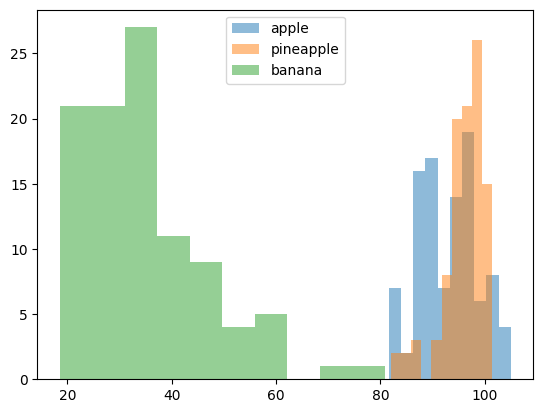

In [30]:
plt.hist(apple_means, alpha=0.5, label='apple')
plt.hist(pineapple_means, alpha=0.5, label='pineapple')
plt.hist(banana_means, alpha=0.5, label='banana')

plt.legend()
plt.show()

과일 이미지에서 모든 픽셀(100x100)의 평균값을 사용하면 바나나를 다른 과일들과 구분하기는 쉬울 것 같지만, 사과와 파인애플은 평균값이 분포하는 구간이 비슷해서 구분이 어려울 것 같다.

## 과일 샘플들에서 같은 위치의 픽셀들의 평균

In [36]:
apple_px_means = apples.mean(axis=0)
pineapple_px_means = pineapples.mean(axis=0)
banana_px_means = bananas.mean(axis=0)

In [37]:
apple_px_means.shape  # (10_000,) 모양의 1차원 배열

(10000,)

픽셀 평균들의 막대 그래프

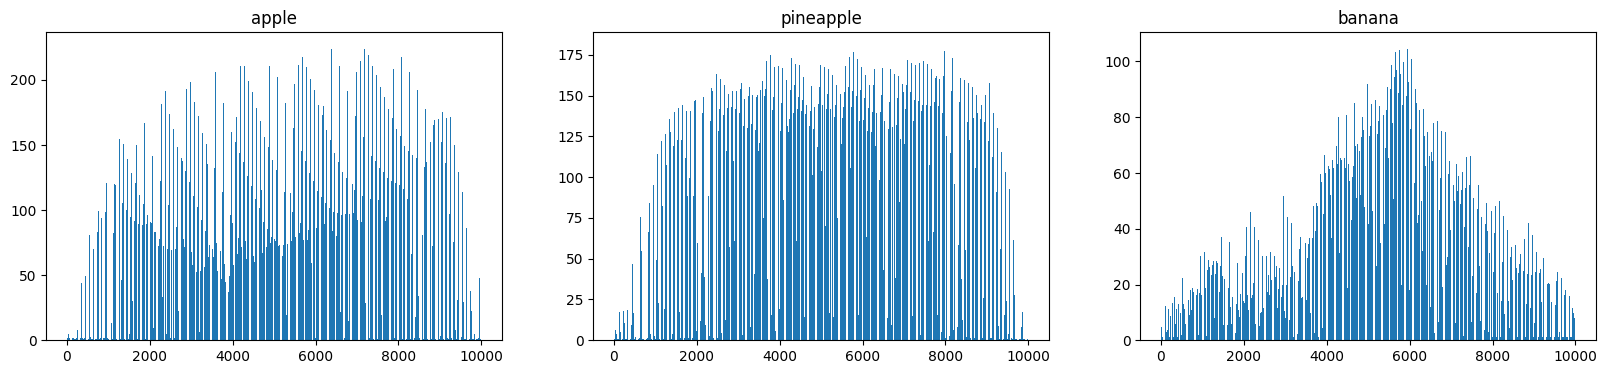

In [38]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 4))
x = np.arange(10_000)  # 0 ~ 9,999

axes[0].bar(x, apple_px_means)
axes[0].set_title('apple')

axes[1].bar(x, pineapple_px_means)
axes[1].set_title('pineapple')

axes[2].bar(x, banana_px_means)
axes[2].set_title('banana')

plt.show()

*   각 픽셀 평균값(apple_px_means, pineapple_px_means, banana_px_means)는 (10_000,) 모양의 1차원 배열
*   (100, 100) 모양의 2차원 배열로 변환
*   이미지 시각화(`imshow()` 사용)

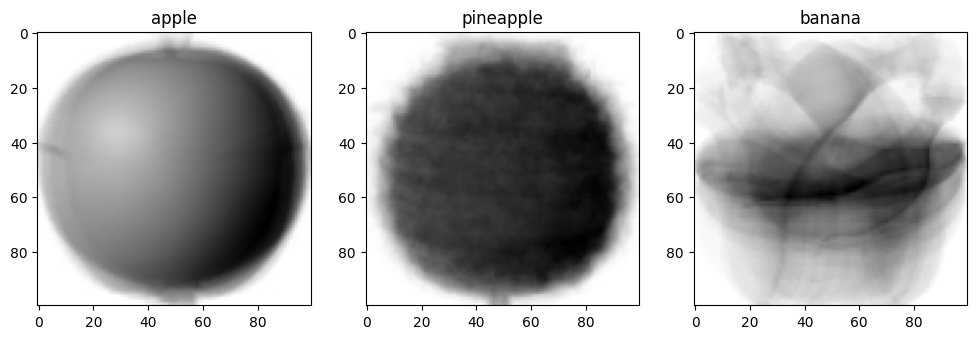

In [39]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))

axes[0].imshow(apple_px_means.reshape((100, 100)), cmap=plt.cm.binary)
axes[0].set_title('apple')

axes[1].imshow(pineapple_px_means.reshape((100, 100)), cmap=plt.cm.binary)
axes[1].set_title('pineapple')

axes[2].imshow(banana_px_means.reshape((100, 100)), cmap=plt.cm.binary)
axes[2].set_title('banana')

plt.show()

# 픽셀 평균값 배열과 거리가 가까운 이미지 찾기

In [40]:
fruits_2d.shape  # (300, 10_000)

(300, 10000)

사과 픽셀 평균값과 가까운 이미지

In [41]:
apple_px_means.shape  # (10_000)

(10000,)

$$
d = \sqrt{\sum_{i=1}^{n} (x_{1i} - x_{2i})^2}
$$

In [44]:
distances = np.sqrt(np.sum((fruits_2d - apple_px_means) ** 2, axis=1))

In [45]:
distances.shape
#> (300,)
#> 300개의 과일에서 사과 픽셀 평균값들까지의 거리

(300,)

In [48]:
# np.argsort(array): 배열 array를 오름차순 정렬한 배열의 인덱스를 리턴.
apple_like_idx = np.argsort(distances)[:100]
apple_like_idx

array([ 12,  38,  30,  47,  76,  84,  66,  53,  24,  48,  69,  87,  33,
        27,  73,  70,  57,  68,  74,  86,   7,  54,  11,  90,  56,  61,
        31,  16,  98,   4,  78,  14,   1,  93,  59,   6,  49,  92,  40,
        23,  50,  32,  36,  71,  95,   8,  77,  10,   3,  65,   0,  94,
         2,  22,  80,  89,  97,  17,  96,  41,  39,  75,  35,  21,  55,
        43,  99,  28,  13,  64,  34,  82,  15,  25,  19,  67,  46,  58,
        79,  51,  60,  20,  37,  29,  83,  85,  81,   9,  45,  88,  26,
        63, 110, 120, 124,   5,  72, 192, 109, 102])

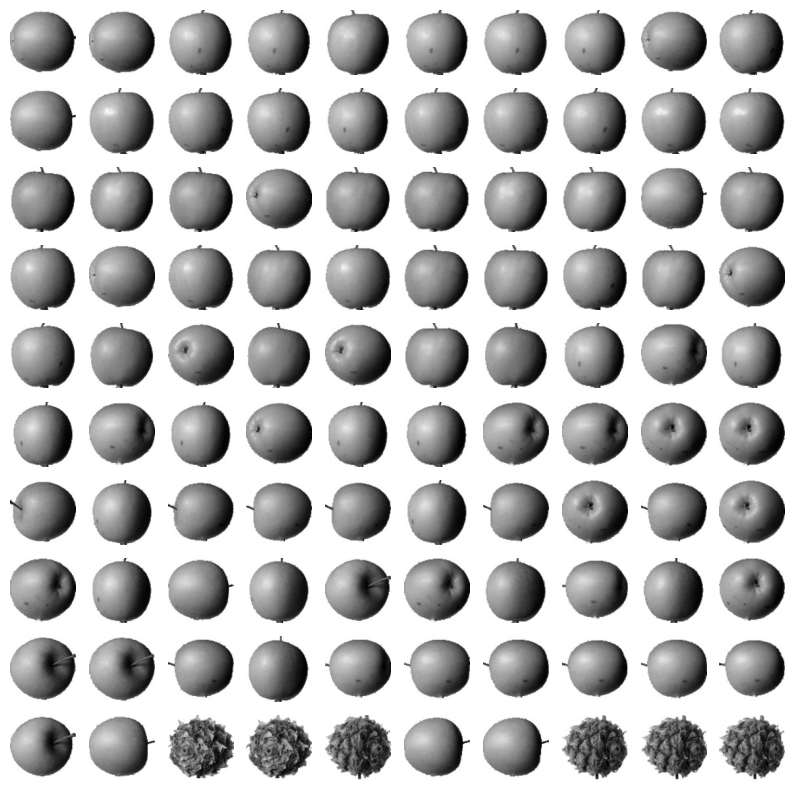

In [51]:
# 사과 픽셀 평균값들과 가까운 100개의 과일들을 시각화.
plot_img_array(fruits[apple_like_idx])

파인애플 픽셀 평균값과 가까운 과일 100개

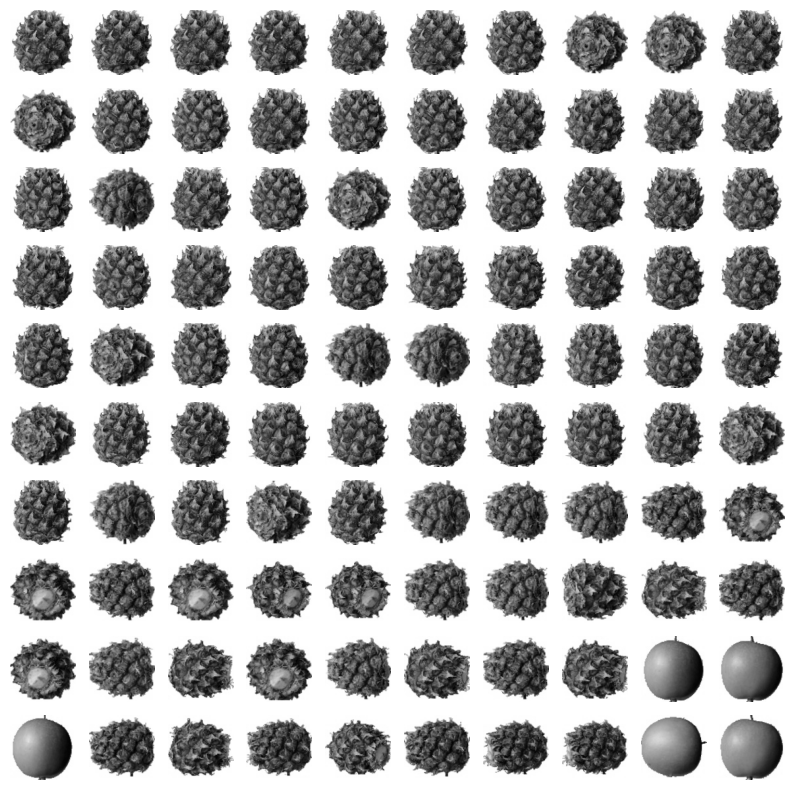

In [53]:
distances = np.sqrt(np.sum((fruits_2d - pineapple_px_means) ** 2, axis=1))
pineapple_like_idx = np.argsort(distances)[:100]
plot_img_array(fruits[pineapple_like_idx])

바나나 픽셀 평균값과 가깡운 과일 100개

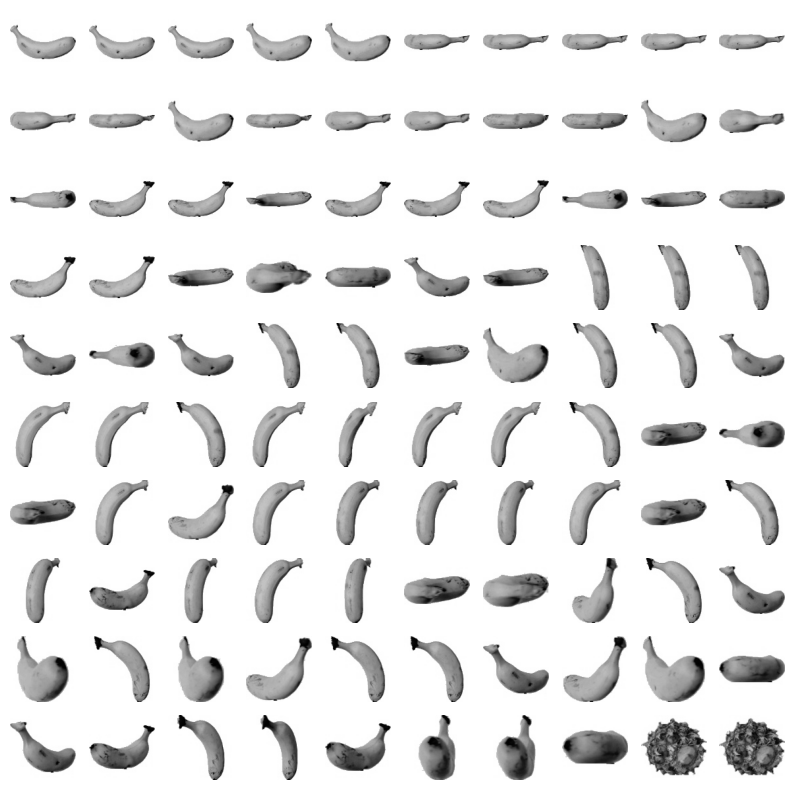

In [54]:
distances = np.sqrt(np.sum((fruits_2d - banana_px_means) ** 2, axis=1))
banana_like_idx = np.argsort(distances)[:100]
plot_img_array(fruits[banana_like_idx])